# Imports

In [1]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")
 
import os
import sys
import time
import logging
from pathlib import Path
 
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA

import torch
import torch_geometric
import torch_scatter
import torch_sparse
import torch_cluster

# USER CONFIGURATION — edit these to match your environment

In [ ]:
# =============================================================================
# USER CONFIGURATION — edit these to match your environment
# =============================================================================
 
# Path to cloned SpaCross repo (for SpaCross package + Config/DLPFC.yaml)
SPACROSS_ROOT = Path(r"/home/dal875013/work/projects/mocha/methods/spacross/SpaCross")
 
# Path to the folder containing SCE_151*.h5ad files
DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")
 
# Output folder for parquet results
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/dlpfc_spacross")
 
# SpaCross config (the repo's Config/DLPFC.yaml)
CONFIG_PATH = SPACROSS_ROOT / "Config" / "DLPFC.yaml"
 
#All 12 DLPFC slice IDs (matches your screenshot)
ALL_DLPFC_SAMPLES = [
    "151507", "151508", "151509", "151510",
    "151669", "151670", "151671", "151672",
    "151673", "151674", "151675", "151676",
]
# ALL_DLPFC_SAMPLES = [
#     "151507",
# ]

# ----- SUBSET SELECTOR -----------------------------------------------------
# Set SAMPLES_TO_RUN to:
#   - None or "all" → run all 12 slices
#   - A list like ["151507", "151673"] → only run those slices
#   - A single string "151675" → run just that one
#
# Examples (uncomment one):
# SAMPLES_TO_RUN = None                         # all 12
# SAMPLES_TO_RUN = ["151673", "151674"]         # subset
# SAMPLES_TO_RUN = "151675"                     # just one
SAMPLES_TO_RUN = None
 
# Method name (written to the 'method' column in parquet files)
METHOD_NAME = "SpaCross"
 
# Clustering algorithm for the latent embedding: "mclust" (needs R+mclust) or "kmeans"
CLUST_METHOD = "mclust"

# Number of runs per slice (>1 enables variance estimation)
NUM_RUNS = 1
 
# Which column in adata.obs holds the ground-truth layer labels.
# Leave as None to auto-detect from common names:
#   layer_guess, layer_guess_reordered, Ground Truth, ground_truth, layer, Layer
GT_LABEL_COL = "z"


# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    """Return 'cuda:0' if a CUDA GPU is available, else 'cpu'. Logs details."""
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available — using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU detected — falling back to CPU (slow)")
    return dev

# Logging setup
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")


# =============================================================================
# Helpers
# =============================================================================
def resolve_samples(selector) -> list:
    """Turn SAMPLES_TO_RUN into a concrete list of slice IDs."""
    if selector is None or selector == "all":
        return list(ALL_DLPFC_SAMPLES)
    if isinstance(selector, str):
        return [selector]
    if isinstance(selector, (list, tuple)):
        return list(selector)
    raise ValueError(f"Unrecognized SAMPLES_TO_RUN value: {selector!r}")
 
 
def get_num_clusters(sample_id: str) -> int:
    """5 layers for slices 151669-151672, otherwise 7 (per SpaCross paper)."""
    return 5 if sample_id in {"151669", "151670", "151671", "151672"} else 7
 
 
def detect_gt_column(adata) -> str:
    """Auto-detect which obs column holds the ground-truth layer label."""
    if GT_LABEL_COL is not None:
        if GT_LABEL_COL not in adata.obs.columns:
            raise KeyError(
                f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
                f"Available columns: {list(adata.obs.columns)}"
            )
        return GT_LABEL_COL
 
    candidates = [
        "layer_guess", "layer_guess_reordered", "layer_guess_reordered_short",
        "Ground Truth", "ground_truth", "GroundTruth",
        "layer", "Layer", "annotation", "Annotation",
    ]
    for c in candidates:
        if c in adata.obs.columns:
            return c
    raise KeyError(
        f"Could not auto-detect ground-truth column. "
        f"adata.obs columns: {list(adata.obs.columns)}. "
        f"Please set GT_LABEL_COL manually."
    )

# Data loading  (adapted for .h5ad input)

In [3]:
# =============================================================================
# Data loading  (adapted for .h5ad input)
# =============================================================================
def load_dlpfc_sample(config: dict, sample_id: str, tools_mod):
    """
    Load and preprocess a single DLPFC .h5ad file, reproducing the preprocessing
    from the SpaCross notebook (but reading .h5ad instead of raw Visium dirs).
 
    Returns:
        adata_proc : preprocessed AnnData
        edge_index : torch sparse tensor (k-NN graph from spatial coords)
        gt_col     : name of the ground-truth obs column used
    """
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")
 
    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()
 
    # ---- DIAGNOSTIC: initial shape / obs columns / obsm keys ----
    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")
 
    # ---- Ground-truth label column ----
    gt_col = detect_gt_column(adata)
    adata.obs["layer_guess"] = adata.obs[gt_col].astype(object)
    n_labeled = adata.obs["layer_guess"].notna().sum()
    logging.info(
        f"  [DIAG] Using GT column '{gt_col}'  "
        f"(labeled spots: {n_labeled}/{adata.n_obs})"
    )
 
    # This dataset uses obsm['S'] as the spatial key instead of 'spatial'.
    # SpaCross.graph_construction expects 'spatial' by default, so we alias it.
    if "spatial" not in adata.obsm:
        if "S" in adata.obsm:
            adata.obsm["spatial"] = adata.obsm["S"]
            logging.info("  [DIAG] Aliased obsm['S'] -> obsm['spatial']")
        else:
            raise KeyError(
                f"No spatial coordinates found in {h5ad_path}. "
                f"Available obsm keys: {list(adata.obsm.keys())}"
            )
    logging.info(
        f"  [DIAG] spatial coords shape: {adata.obsm['spatial'].shape}"
)
 
    # ---- Build k-NN spatial graph ----
    k = config["data"]["k_cutoff"]
    edge_index = tools_mod.graph_construction(adata, k)
    logging.info(
        f"  [DIAG] Built k-NN graph (k={k}): edge_index type={type(edge_index).__name__}"
    )
 
    # ---- Preprocessing (mirrors the notebook exactly) ----
    # Store raw counts in a layer. Handles both sparse and dense .X.
    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()
 
    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    logging.info(
        f"  [DIAG] After gene filtering: n_vars={adata.n_vars}"
    )
 
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        layer="count",
        n_top_genes=config["data"]["top_genes"],
    )
    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)
    logging.info(
        f"  [DIAG] After HVG selection: n_vars={adata.n_vars} "
        f"(target top_genes={config['data']['top_genes']})"
    )
 
    # ---- PCA to 200 components ----
    n_pcs = min(200, adata.n_vars, adata.n_obs)
    adata.obsm["X_pca"] = PCA(n_components=n_pcs, random_state=42).fit_transform(
        adata.X
    )
    logging.info(f"  [DIAG] PCA done: X_pca shape={adata.obsm['X_pca'].shape}")
 
    return adata, edge_index, gt_col

# Train one slice

In [4]:
# =============================================================================
# Train one slice
# =============================================================================
def train_one_slice(
    sample_id: str,
    adata,
    edge_index,
    config: dict,
    device: str,
    tools_mod,
    clust_method: str = "mclust",
    run_seed: int = 0,
):
    """
    Train SpaCross on one slice and compute ARI/ACC/DIS.
 
    Returns:
        metrics: dict of scalar metrics + timing
        pred_df: DataFrame with one row per spot  — columns:
            method, sample, spot_id, true_label, pred_label, run_seed
    """
    NUM_CLUSTERS_DLPFC = 7
    num_clusters = NUM_CLUSTERS_DLPFC
    logging.info(
        f"  [TRAIN] Starting SpaCross  | slice={sample_id} | "
        f"k_clusters={num_clusters} | device={device} | run_seed={run_seed}"
    )
 
    t0 = time.time()
 
    # Build pipeline
    net = tools_mod.SC_pipeline(
        adata,
        edge_index=edge_index,
        num_clusters=num_clusters,
        device=device,
        config=config,
        roundseed=run_seed,
        imputation=False,
    )
 
    # Train (note the intentional typo in SpaCross API: .trian() not .train())
    net.trian()
 
    # Extract latent + reconstruction
    enc_rep, recon = net.process()
    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon
    logging.info(
        f"  [DIAG] Latent shape: {enc_rep.shape}  "
        f"Recon shape: {recon.shape}"
    )
 
    # Cluster in latent space
    pred_labels = tools_mod.clustering(
        z=enc_rep,
        n_clust=num_clusters,
        num_seed=1,
        method=clust_method,
    )
    adata.obs[clust_method] = pred_labels
    logging.info(
        f"  [DIAG] Cluster sizes: "
        f"{pd.Series(pred_labels).astype(str).value_counts().to_dict()}"
    )
 
    elapsed = time.time() - t0
 
    # ---- Metrics on labeled spots only ----
    sub_adata = adata[~pd.isnull(adata.obs["layer_guess"])]
    # ARI, ACC = mean(NMI, HOM, COM), DIS = mean(CHAOS, PAS)
    ARI, ACC, DIS = tools_mod.get_metrics(sub_adata, "layer_guess", clust_method)
    # NMI is also reported standalone (not only inside ACC)
    from SpaCross.Utils import compute_NMI
    NMI = compute_NMI(sub_adata, "layer_guess", clust_method)
 
    # GPU model: resolve the actual card name once per run so it lands in parquet
    gpu_name = (
        torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
    )
 
    metrics = {
        "method": METHOD_NAME,
        "sample": sample_id,
        "run_seed": run_seed,
        "ARI": float(ARI),
        "ACC": float(ACC),
        "DIS": float(DIS),
        "NMI": float(NMI),
        "running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "clust_method": clust_method,
        "device": device,
    }
    logging.info(
        f"  [METRICS] ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
        f"DIS={DIS:.4f}  time={elapsed:.1f}s  gpu={gpu_name}"
    )
 
    # ---- Per-spot predictions (for predictions.parquet) ----
    pred_df = pd.DataFrame(
        {
            "method": METHOD_NAME,
            "sample": sample_id,
            "run_seed": run_seed,
            "spot_id": adata.obs_names.astype(str).to_numpy(),
            "true_label": adata.obs["layer_guess"].astype(object).to_numpy(),
            "pred_label": np.asarray(adata.obs[clust_method]).astype(str),
        }
    )
 
    return metrics, pred_df

# Main benchmark loop

In [5]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)
 
    logging.info("=" * 72)
    logging.info("SpaCross DLPFC Benchmarking Framework")
    logging.info("=" * 72)
 
    # --- Register SpaCross package ---
    if not SPACROSS_ROOT.exists():
        raise FileNotFoundError(
            f"SPACROSS_ROOT not found: {SPACROSS_ROOT.resolve()}\n"
            f"Clone it with:  git clone https://github.com/wenwenmin/SpaCross.git"
        )
    sys.path.insert(0, str(SPACROSS_ROOT.resolve()))
    import SpaCross as TOOLS  # noqa: N814
 
    # --- Device ---
    device = get_device()
 
    # --- Data root sanity check ---
    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] SPACROSS_ROOT = {SPACROSS_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR.resolve()}")
 
    # --- Config ---
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
    logging.info(f"[CONFIG] {config}")
 
    # --- Which slices to run ---
    samples = resolve_samples(SAMPLES_TO_RUN)
    logging.info(f"[SAMPLES] Will process {len(samples)} slice(s): {samples}")
    logging.info(f"[SETTINGS] clust_method={CLUST_METHOD}  num_runs={NUM_RUNS}")
 
    all_metrics = []
    all_predictions = []
    failed = []
 
    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(samples)}] Slice {sample_id}")
        logging.info("-" * 72)
 
        try:
            adata, edge_index, gt_col = load_dlpfc_sample(
                config, sample_id, TOOLS
            )
 
            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")
                adata_run = adata.copy()  # avoid cross-run contamination
 
                metrics, pred_df = train_one_slice(
                    sample_id=sample_id,
                    adata=adata_run,
                    edge_index=edge_index,
                    config=config,
                    device=device,
                    tools_mod=TOOLS,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )
                metrics["gt_col"] = gt_col
                all_metrics.append(metrics)
                all_predictions.append(pred_df)
 
            # Free GPU memory between slices
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
 
        except Exception as e:
            logging.exception(f"[FAILED] Slice {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})
            continue
 
    # =========================================================================
    # Save in team-standard parquet format
    # =========================================================================
    if not all_metrics:
        logging.error("No successful runs — nothing to save.")
        return
 
    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)
 
    # Reorder columns (put identifiers first, then metrics, then diagnostics)
    perf_lead = ["method", "sample", "run_seed",
                 "ARI", "NMI", "ACC", "DIS",
                 "running_time_sec", "gpu_model"]
    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]
    pred_lead = ["method", "sample", "run_seed", "spot_id",
                 "true_label", "pred_label"]
    predictions = predictions[pred_lead]
 
    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"
    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)
 
    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)
    logging.info(f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)")
    logging.info(f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)")
 
    # ---- Per-sample summary ----
    logging.info("")
    logging.info("Per-sample metrics:")
    logging.info("\n" + performance[
        ["sample", "ARI", "NMI", "ACC", "DIS", "running_time_sec"]
    ].to_string(index=False))
 
    logging.info("")
    logging.info(f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
                 f"NMI: {performance['NMI'].mean():.4f}  "
                 f"ACC: {performance['ACC'].mean():.4f}  "
                 f"DIS: {performance['DIS'].mean():.4f}")
    logging.info(f"GPU model(s) used: "
                 f"{sorted(performance['gpu_model'].unique().tolist())}")
    logging.info(f"Total running time: "
                 f"{performance['running_time_sec'].sum():.1f}s")
 
    if failed:
        logging.warning(f"\n{len(failed)} slice(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['sample']}: {f_['error']}")
 
    logging.info("\nBenchmarking complete.")
 
 
if __name__ == "__main__":
    run_benchmark()

2026-04-27 19:39:47,467 [INFO] Log file: /home/dal875013/work/projects/mocha/results/dlpfc_spacross/benchmark.log
2026-04-27 19:39:47,467 [INFO] ========================================================================
2026-04-27 19:39:47,468 [INFO] SpaCross DLPFC Benchmarking Framework
2026-04-27 19:39:47,468 [INFO] ========================================================================


2026-04-27 19:39:47,971 [INFO] cffi mode is CFFI_MODE.ANY
2026-04-27 19:39:48,155 [INFO] R home found: /work/dal875013/conda_envs/spacross_env/lib/R
2026-04-27 19:39:49,540 [INFO] R library path: /work/dal875013/conda_envs/spacross_env/lib:
2026-04-27 19:39:49,541 [INFO] LD_LIBRARY_PATH: /work/dal875013/conda_envs/spacross_env/lib
2026-04-27 19:39:49,566 [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-04-27 19:39:50,364 [INFO] R is already initialized. No need to initialize.
2026-04-27 19:39:53,074 [INFO] [DEVICE] CUDA available — using cuda:0
2026-04-27 19:39:53,114 [INFO] [DEVICE] GPU name: NVIDIA A30
2026-04-27 19:39:53,115 [INFO] [DEVICE] GPU memory: 25.22 GB
2026-04-27 19:39:53,124 [INFO] [PATHS] SPACROSS_ROOT = /work/dal875013/projects/mocha/methods/spacross/SpaCross
2026-04-27 19:39:53,127 [INFO] [PATHS] DATA_ROOT     = /groups/qiwei/mocha/QuickSRT/DLPFC_10x/data
2026-04-27 19:39:53,132 [INFO] [PATHS] OUTPUT_DIR    = /work/dal875013/projects/mocha/results/d

Epoch 299 total loss=1.566 recon loss=1.049 mean loss=0.407 tri loss=1.357: 100%|██████████| 300/300 [00:09<00:00, 31.20it/s]


2026-04-27 19:40:08,343 [INFO]   [DIAG] Latent shape: (4226, 16)  Recon shape: (4226, 200)
[DEBUG mclust] emb shape = (4226, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-27 19:40:14,083 [INFO]   [DIAG] Cluster sizes: {'5': 1011, '4': 801, '2': 801, '3': 685, '7': 416, '1': 316, '6': 196}
2026-04-27 19:40:15,177 [INFO]   [METRICS] ARI=0.4636  NMI=0.6187  ACC=0.6187  DIS=0.0378  time=16.0s  gpu=NVIDIA A30
2026-04-27 19:40:15,201 [INFO] 
2026-04-27 19:40:15,203 [INFO] ------------------------------------------------------------------------
2026-04-27 19:40:15,204 [INFO] [2/12] Slice 151508
2026-04-27 19:40:15,204 [INFO] ------------------------------------------------------------------------
2026-04-27 19:40:15,205 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/DLPFC_10x/data/SCE_151508.h5ad
2026-04-27 19:40:15,596 [INFO]   [DIAG] Loaded AnnData: n_obs=4384, n_vars=33538
2026-04-27 19:40:15,598 [INFO]   [DIA

Epoch 299 total loss=1.579 recon loss=1.069 mean loss=0.403 tri loss=1.361: 100%|██████████| 300/300 [00:08<00:00, 36.11it/s]


...

2026-04-27 19:43:31,309 [INFO]   [DIAG] Latent shape: (3592, 16)  Recon shape: (3592, 200)


[DEBUG mclust] emb shape = (3592, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-27 19:43:36,012 [INFO]   [DIAG] Cluster sizes: {'1': 954, '2': 695, '4': 584, '6': 528, '5': 395, '3': 250, '7': 186}
2026-04-27 19:43:36,793 [INFO]   [METRICS] ARI=0.6353  NMI=0.7363  ACC=0.7364  DIS=0.0371  time=12.0s  gpu=NVIDIA A30
2026-04-27 19:43:36,798 [INFO] 
2026-04-27 19:43:36,799 [INFO] ------------------------------------------------------------------------
2026-04-27 19:43:36,800 [INFO] [12/12] Slice 151676
2026-04-27 19:43:36,800 [INFO] ------------------------------------------------------------------------
2026-04-27 19:43:36,801 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/DLPFC_10x/data/SCE_151676.h5ad
2026-04-27 19:43:37,350 [INFO]   [DIAG] Loaded AnnData: n_obs=3460, n_vars=33538
2026-04-27 19:43:37,352 [INFO]   [DIAG] obs columns: ['z']
2026-04-27 19:43:37,352 [INFO]   [DIAG] obsm keys  : ['S']
2026-04-27

Epoch 299 total loss=1.534 recon loss=0.988 mean loss=0.403 tri loss=1.367: 100%|██████████| 300/300 [00:07<00:00, 41.84it/s]

2026-04-27 19:43:47,834 [INFO]   [DIAG] Latent shape: (3460, 16)  Recon shape: (3460, 200)


[DEBUG mclust] emb shape = (3460, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-27 19:43:53,209 [INFO]   [DIAG] Cluster sizes: {'2': 999, '1': 705, '5': 637, '4': 405, '3': 369, '7': 193, '6': 152}
2026-04-27 19:43:54,094 [INFO]   [METRICS] ARI=0.5153  NMI=0.6492  ACC=0.6494  DIS=0.0384  time=12.6s  gpu=NVIDIA A30
2026-04-27 19:43:54,250 [INFO] 
2026-04-27 19:43:54,251 [INFO] ========================================================================
2026-04-27 19:43:54,252 [INFO] SAVED
2026-04-27 19:43:54,252 [INFO] ========================================================================
2026-04-27 19:43:54,253 [INFO]   predictions.parquet -> /home/dal875013/work/projects/mocha/results/dlpfc_spacross/predictions.parquet  (47,681 rows)
2026-04-27 19:43:54,253 [INFO]   performance.parquet -> /home/dal875013/work/projects/mocha/results/dlpfc_spacross/performance.parquet  (12 rows)
2026-04-27 19:43:54,254 [INFO] 
2026

# prediction results visulization

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


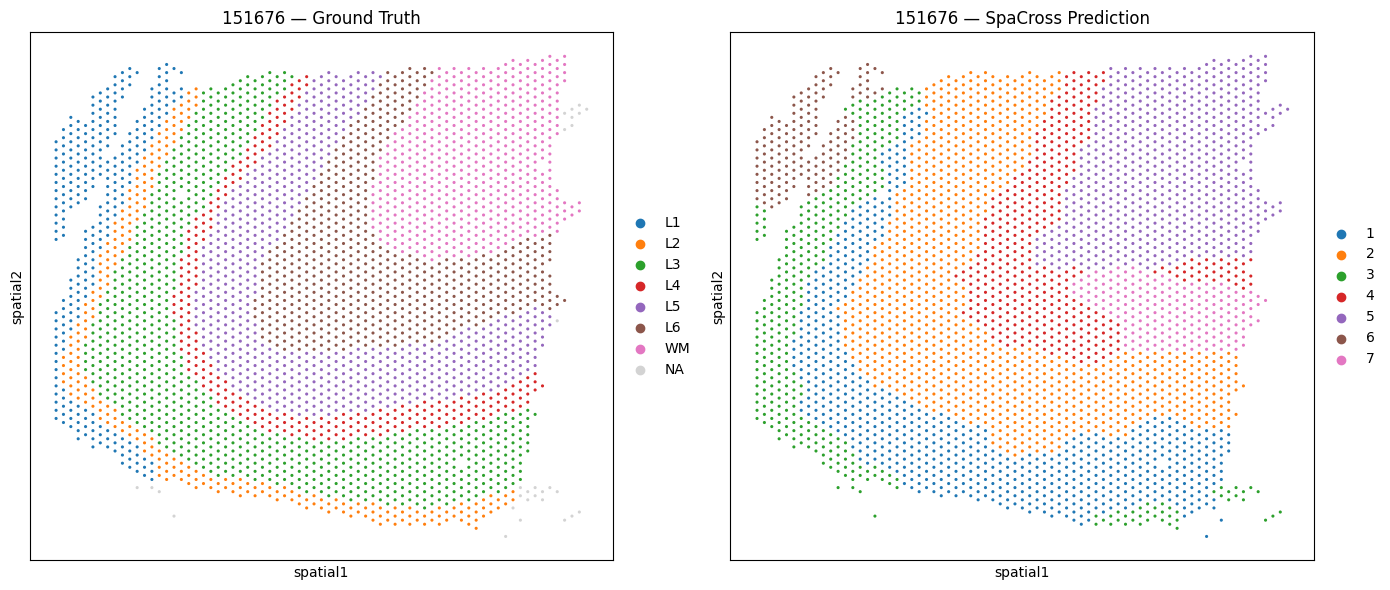

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/dlpfc_spacross")

SAMPLE_ID = "151676"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")
pred_slice = predictions[predictions["sample"] == SAMPLE_ID].set_index("spot_id")
adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")

adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values
adata.obsm["spatial"] = np.asarray(adata.obsm["S"])   # ← 这里改了

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.embedding(adata, basis="spatial", color="true_label",
                ax=axes[0], show=False, title=f"{SAMPLE_ID} — Ground Truth", s=20)
sc.pl.embedding(adata, basis="spatial", color="pred_label",
                ax=axes[1], show=False, title=f"{SAMPLE_ID} — SpaCross Prediction", s=20)
axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

# Running results summary

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/dlpfc_spacross")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)

performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "sample", "run_seed", "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "clust_method", "gpu_model"
]

display_cols = [c for c in display_cols if c in performance.columns]

print("===== All SpaCross results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary = performance[["ARI", "NMI", "ACC", "DIS", "running_time_sec"]].describe()
display(summary)

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")

===== All SpaCross results =====


,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,clust_method,gpu_model
0,151507,0,0.463563,0.618678,0.618679,0.037820,7,4226,4221,24.84,mclust,NVIDIA A30
1,151508,0,0.409237,0.571395,0.571451,0.037850,7,4384,4381,14.74,mclust,NVIDIA A30
2,151509,0,0.613375,0.716922,0.717352,0.033503,7,4789,4788,16.77,mclust,NVIDIA A30
3,151510,0,0.568824,0.676229,0.676838,0.036217,7,4634,4595,16.30,mclust,NVIDIA A30
4,151669,0,0.474487,0.574786,0.575620,0.036373,5,3661,3636,14.80,mclust,NVIDIA A30
5,151670,0,0.385907,0.518114,0.522051,0.036246,5,3498,3484,13.32,mclust,NVIDIA A30
6,151671,0,0.527182,0.598027,0.598192,0.033152,5,4110,4093,14.24,mclust,NVIDIA A30
7,151672,0,0.581922,0.687056,0.687591,0.036160,5,4015,3888,13.86,mclust,NVIDIA A30
8,151673,0,0.607503,0.711878,0.711903,0.037665,7,3639,3611,16.29,mclust,NVIDIA A30
9,151674,0,0.475707,0.627821,0.627864,0.037819,7,3673,3635,16.10,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,0.521525,0.640539,0.641110,0.036531,15.553333
std,0.081692,0.067522,0.066907,0.001686,3.253441
min,0.385907,0.518114,0.522051,0.033152,12.460000
25%,0.471756,0.592217,0.592549,0.036202,13.725000
50%,0.521224,0.638531,0.638634,0.036747,14.770000
75%,0.588317,0.693262,0.693669,0.037819,16.292500
max,0.635330,0.736324,0.736371,0.038440,24.840000



===== Mean metrics =====
Mean ARI: 0.5215
Mean NMI: 0.6405
Mean ACC: 0.6411
Mean DIS: 0.0365

===== Best / worst ARI =====
Best ARI : 151675  ARI=0.6353
Worst ARI: 151670  ARI=0.3859


# actual layer in ground truth checking

In [1]:
import scanpy as sc
import pandas as pd
from pathlib import Path

DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")

ALL_DLPFC_SAMPLES = [
    "151507", "151508", "151509", "151510",
    "151669", "151670", "151671", "151672",
    "151673", "151674", "151675", "151676",
]

results = []

for sample_id in ALL_DLPFC_SAMPLES:
    path = DATA_ROOT / f"SCE_{sample_id}.h5ad"

    if not path.exists():
        print(f"[MISSING] {sample_id}: {path}")
        continue

    adata = sc.read_h5ad(path)

    if "z" not in adata.obs:
        print(f"[NO LABEL] {sample_id}; obs columns = {list(adata.obs.columns)}")
        continue

    labels_all = adata.obs["z"]

    # remove NaN labels
    labels = labels_all.dropna()

    unique_labels = sorted(labels.unique())
    n_classes = len(unique_labels)

    results.append({
        "sample": sample_id,
        "n_classes": n_classes,
        "labels": unique_labels,
        "n_spots": adata.n_obs,
        "n_labeled": len(labels),
        "n_NA": int(labels_all.isna().sum()),
    })

df = pd.DataFrame(results).sort_values(["n_classes", "sample"])

print("===== DLPFC_10x: Per-sample class counts =====")
display(df)

print("\n===== Summary =====")
print(df["n_classes"].value_counts().sort_index())

print("\n===== Samples with only 1 class =====")
print(df[df["n_classes"] == 1]["sample"].tolist())

print("\n===== Suggested dictionary: sample -> n_classes =====")
cluster_dict = dict(zip(df["sample"], df["n_classes"]))
print(cluster_dict)

===== DLPFC_10x: Per-sample class counts =====


,sample,n_classes,labels,n_spots,n_labeled,n_NA
4,151669,5,"[L3, L4, L5, L6, WM]",3661,3636,25
5,151670,5,"[L3, L4, L5, L6, WM]",3498,3484,14
6,151671,5,"[L3, L4, L5, L6, WM]",4110,4093,17
7,151672,5,"[L3, L4, L5, L6, WM]",4015,3888,127
0,151507,7,"[L1, L2, L3, L4, L5, L6, WM]",4226,4221,5
1,151508,7,"[L1, L2, L3, L4, L5, L6, WM]",4384,4381,3
2,151509,7,"[L1, L2, L3, L4, L5, L6, WM]",4789,4788,1
3,151510,7,"[L1, L2, L3, L4, L5, L6, WM]",4634,4595,39
8,151673,7,"[L1, L2, L3, L4, L5, L6, WM]",3639,3611,28
9,151674,7,"[L1, L2, L3, L4, L5, L6, WM]",3673,3635,38



===== Summary =====
n_classes
5    4
7    8
Name: count, dtype: int64

===== Samples with only 1 class =====
[]

===== Suggested dictionary: sample -> n_classes =====
{'151669': 5, '151670': 5, '151671': 5, '151672': 5, '151507': 7, '151508': 7, '151509': 7, '151510': 7, '151673': 7, '151674': 7, '151675': 7, '151676': 7}
